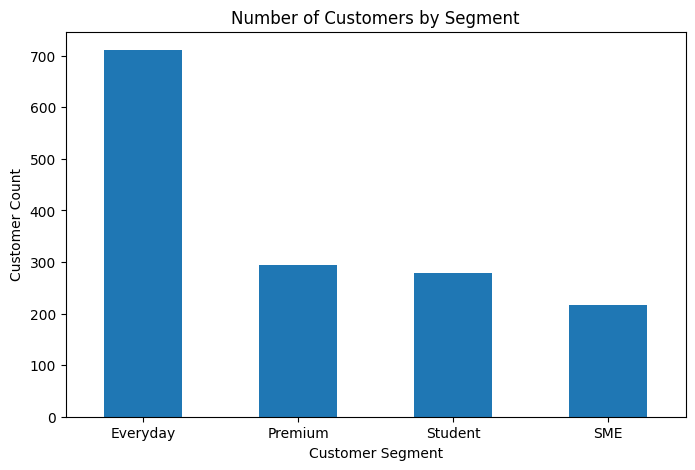

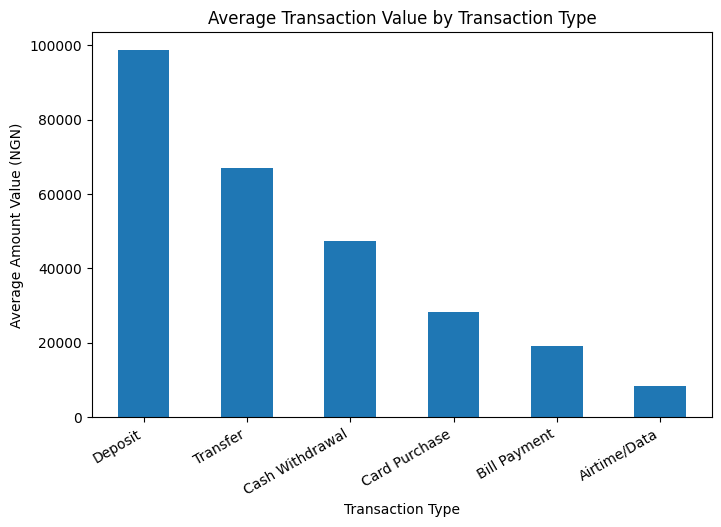

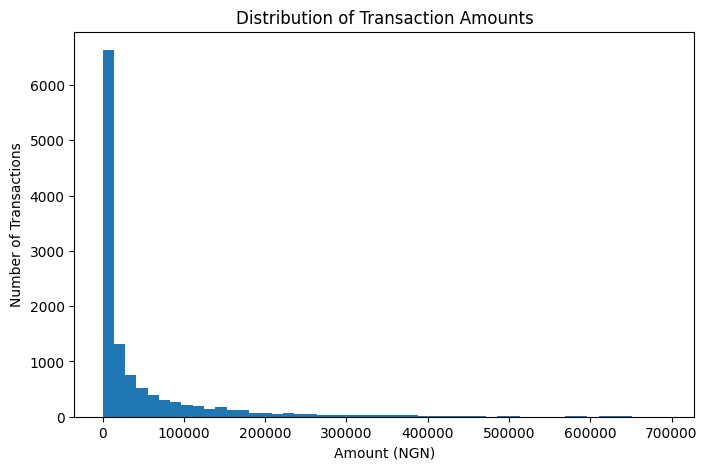

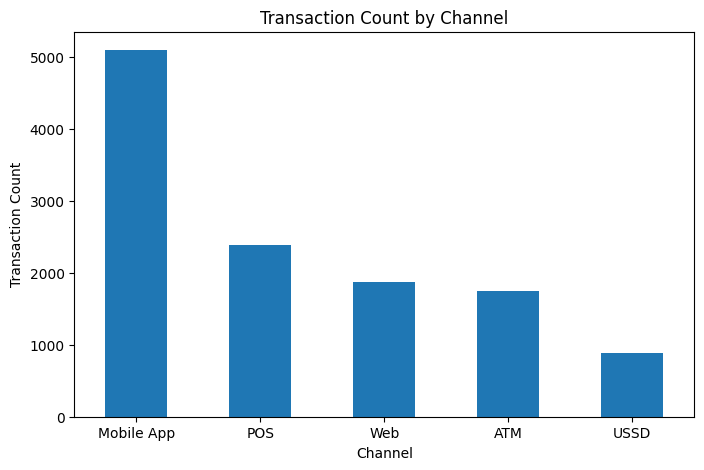

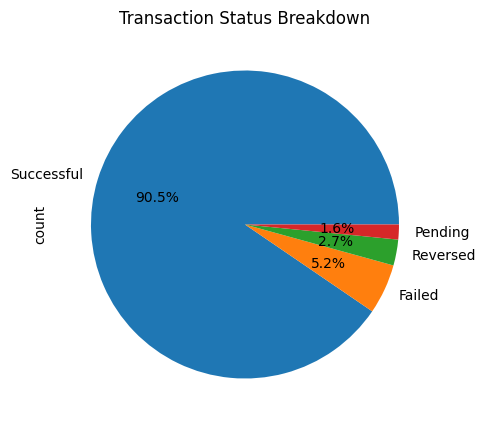

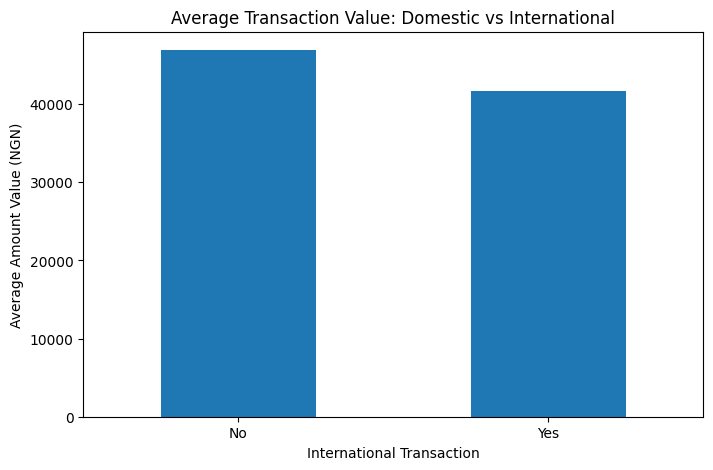

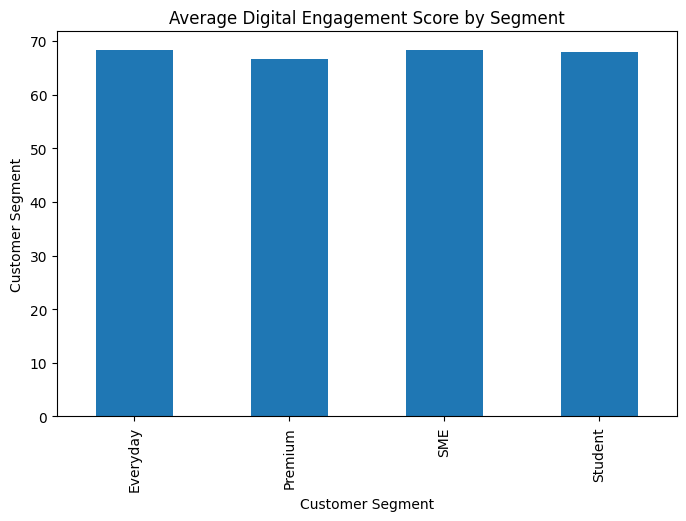

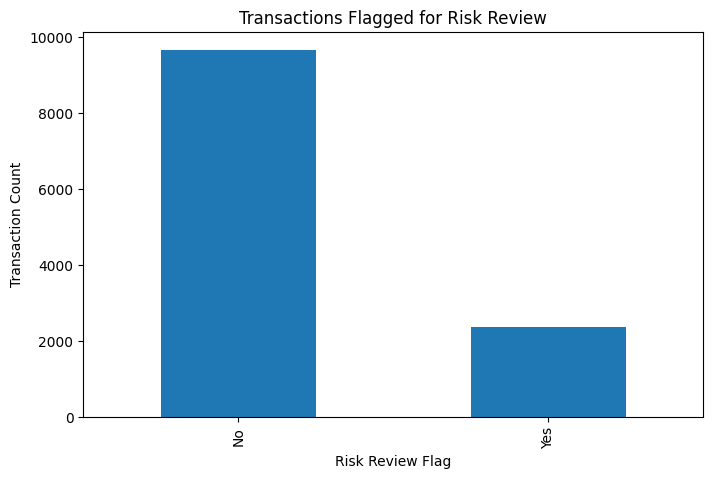

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_csv("FinTrust_Customer_Data - FinTrust_Customer_Data.csv")
transactions = pd.read_csv("FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv")

transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_DateTime'])

plt.rcParams['figure.figsize'] = (8, 5)

# 1. Number of Customers by Segment
# What does it show? A bar chart comparing how many customers fall into each segment — Everyday, Premium, Student, SME.
# Why is it important? Segment size shapes how every other metric should be read — if one segment is much larger, it will naturally dominate total volume and value numbers even if it isn't the most valuable per customer.
# Business insight: Everyday customers make up nearly half the base (711 of 1,500). Any total-value or total-volume metric that looks "Everyday-dominated" elsewhere in the analysis is explained by this — it's a base-size effect, not necessarily a behavioural one.
seg_counts = customers['Customer_Segment'].value_counts()
plt.figure()
seg_counts.plot(kind='bar')
plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Customer Count')
plt.xticks(rotation=0)
plt.show()


#2. Average Transaction Value by Transaction Type
# What does it show? A bar chart ranking transaction types by their average value, from Deposit (highest) to Airtime/Data (lowest).
# Why is it important? It shows where the money concentrates, not just where the volume concentrates — a channel or type can be low-frequency but still economically significant.
# Business insight: Deposits (₦98,633 avg) and Transfers (₦67,038 avg) are the highest-value transaction types. If FinTrust wanted to prioritize fraud monitoring or service reliability investment by financial exposure rather than transaction count, these two types deserve the most attention.
ave_by_type = transactions.groupby('Transaction_Type')['Amount_NGN'].mean().sort_values(ascending=False)
plt.figure()
ave_by_type.plot(kind='bar')
plt.title('Average Transaction Value by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Average Amount Value (NGN)')
plt.xticks(rotation=30, ha='right')
plt.show()


#3. Distribution of Transaction Amounts
# What does it show? A histogram of all 12,000 transaction amounts, showing how frequently each value range occurs.
# Why is it important? Averages alone can mislead — this shows the actual shape of the data. A right-skewed distribution (many small transactions, a few very large ones) explains why the mean (₦46,706) sits well above the median (₦10,306).
#Business insight: Most customer activity is low-value, everyday transacting — the high mean is pulled up by a smaller number of large transactions. Reporting the mean alone in an executive summary would overstate "typical" customer spend; median or segmented averages give a fairer picture.
plt.figure()
plt.hist(transactions['Amount_NGN'], bins=50)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount (NGN)')
plt.ylabel('Number of Transactions')
plt.show()



#4. Transaction Count by Channel
# What does it show? A bar chart of transaction volume across the five channels — Mobile App, POS, Web, ATM, USSD.
# Why is it important? Channel usage tells you where to invest in reliability, UX improvements, and support resources — the busiest channel has the most to lose if something breaks.
# Business insight: Mobile App handles 42.5% of all transactions — more than POS and USSD combined. This channel should be the top priority for uptime monitoring and performance investment, since any outage there affects the largest share of customers.
channel_counts = transactions['Channel'].value_counts()
plt.figure()
channel_counts.plot(kind='bar')
plt.title('Transaction Count by Channel')
plt.xlabel('Channel')
plt.ylabel('Transaction Count')
plt.xticks(rotation=0)
plt.show()



#5. Transaction Status Breakdown
# What does it show? A pie chart splitting all transactions into Successful, Failed, Reversed, and Pending.
# Why is it important? This is the clearest single view of platform reliability — it immediately shows what share of transactions don't complete as intended.
# Business insight? While 90.5% succeed, the remaining 9.5% (Failed + Reversed + Pending) represents close to 1,150 transactions — real customer friction worth root-causing, especially combined with the channel-failure breakdown from the SQL analysis (Mobile App had the most failures).
status_counts = transactions['Transaction_Status'].value_counts()
plt.figure()
status_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Transaction Status Breakdown')
plt.show()


# 6. Average Transaction Value: Domestic vs International
# What does it show? A bar chart comparing the average amount of domestic vs. international transactions.
# Why is it important? International transactions carry different risk profiles (currency exposure, cross-border compliance, fraud vectors), so understanding their typical value matters for risk sizing.
#Business insight: Domestic transactions actually average higher (₦46,917) than international ones (₦41,658) — somewhat counterintuitive, since international transfers are often assumed to be larger. This is worth flagging rather than assuming, since it could affect how risk thresholds are set for international activity.
intl_ave = transactions.groupby('International_Transaction')['Amount_NGN'].mean()
plt.figure()
intl_ave.plot(kind='bar')
plt.title('Average Transaction Value: Domestic vs International')
plt.xlabel('International Transaction')
plt.ylabel('Average Amount Value (NGN)')
plt.xticks(rotation=0)
plt.show()


# 7. Average Digital Engagement Score by Segment
# What does it show? A bar chart comparing average engagement scores across the four customer segments.
# Why is it important? It tests a natural assumption — that "higher-value" segments (like Premium) are also more digitally engaged — against the actual data.
# Business insight: Engagement scores are nearly flat across segments (66.7–68.4), and Premium is actually the lowest, not the highest. This challenges any strategy that assumes Premium customers are FinTrust's most digitally active group — engagement campaigns may need to target by behaviour, not segment label.
engagement_by_seg = customers.groupby('Customer_Segment')['Digital_Engagement_Score'].mean()
plt.figure()
engagement_by_seg.plot(kind='bar')
plt.title('Average Digital Engagement Score by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Customer Segment')
plt.show()



# 8. Transactions Flagged for Risk Review
# What does it show? A bar chart comparing flagged vs. non-flagged transaction counts.
# Why is it important? This is the headline risk-exposure metric — it quantifies how much of the platform's activity requires manual or automated review.
# Business insight: Roughly 1 in 5 transactions (19.6%, or 2,352 of 12,000) are flagged. Combined with the earlier SQL finding that this rate is nearly identical across all customer segments, the flag doesn't appear to be segment-driven — the next investigative step should look at whether it correlates with channel, amount, or transaction type instead.
risk_counts = transactions['Risk_Review_Flag'].value_counts()
plt.figure()
risk_counts.plot(kind='bar')
plt.title('Transactions Flagged for Risk Review')
plt.xlabel('Risk Review Flag')
plt.ylabel('Transaction Count')
plt.show()